# Разбор порогов priority

Этот ноутбук отвечает только за обзор вариантов порогов поверх уже рассчитанного `priority_score`.
Он не меняет ranking formula и не подменяет итоговый ноутбук по `final decision`.


In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные настройки.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория из текущей рабочей директории.')

REPO_ROOT = find_repo_root(Path.cwd()).resolve()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Импортируем helper-модули обзора после добавления src в sys.path.
from exohost.ranking.priority_score import PriorityThresholds
from exohost.reporting.final_decision_review import load_final_decision_review_bundle
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    PRIORITY_LABELS,
    PRIORITY_THRESHOLD_SHARE_LABELS,
    PRIORITY_THRESHOLD_VARIANT_LABELS,
)
from exohost.reporting.priority_threshold_review import (
    PriorityThresholdVariant,
    build_priority_label_transition_frame,
    build_priority_threshold_variant_summary_frame,
    build_priority_variant_by_class_frame,
)


## План

1. Загрузить baseline final decision run.
2. Построить варианты порогов без пересчета ranking formula.
3. Сравнить `high/medium/low` distributions.
4. Посмотреть label transitions относительно baseline.
5. Оценить class-level impact для stricter variants.
6. Решить, нужно ли идти дальше в scaling review.

In [3]:
# Конфигурация ноутбук.
FINAL_DECISION_RUN_DIR = REPO_ROOT / 'artifacts/decisions/hierarchical_final_decision_2026_03_29_075935_878508'

PRIORITY_THRESHOLD_VARIANTS = (
    PriorityThresholdVariant(
        name='baseline',
        thresholds=PriorityThresholds(high_min=0.75, medium_min=0.45),
    ),
    PriorityThresholdVariant(
        name='strict_high_080',
        thresholds=PriorityThresholds(high_min=0.80, medium_min=0.45),
    ),
    PriorityThresholdVariant(
        name='strict_high_medium_085_055',
        thresholds=PriorityThresholds(high_min=0.85, medium_min=0.55),
    ),
)

if not FINAL_DECISION_RUN_DIR.exists():
    raise FileNotFoundError(FINAL_DECISION_RUN_DIR)

In [4]:
# Загружаем final decision bundle и строим review-frame для priority threshold analysis.
bundle = load_final_decision_review_bundle(FINAL_DECISION_RUN_DIR)

priority_review_df = bundle.priority_ranking_df.merge(
    bundle.final_decision_df.loc[:, ['source_id', 'final_coarse_class']],
    on='source_id',
    how='left',
    validate='one_to_one',
)

run_context_df = pd.DataFrame([
    {
        'decision_run_dir': bundle.run_dir.name,
        'n_rows_priority_ranking': int(bundle.priority_ranking_df.shape[0]),
        'n_unique_source_id': int(bundle.priority_ranking_df['source_id'].astype(str).nunique(dropna=False)),
    }
])

display(run_context_df)
display(priority_review_df.head(10))

,decision_run_dir,n_rows_priority_ranking,n_unique_source_id
0,hierarchical_final_decision_2026_03_29_075935_...,177674,177674


,source_id,spec_class,evolution_stage,class_priority_score,host_similarity_score,brightness_score,distance_score,astrometry_score,observability_score,brightness_available,distance_available,astrometry_available,observability_evidence_count,priority_score,priority_label,priority_reason,final_coarse_class
0,3618253627527608832,K,NaN,1.0,0.999988,1.0,1.0,1.0,1.0,True,True,True,3,0.999995,high,сильный host-like сигнал; хорошая наблюдательн...,K
1,1638543767320133248,K,NaN,1.0,0.999985,1.0,1.0,1.0,1.0,True,True,True,3,0.999993,high,сильный host-like сигнал; хорошая наблюдательн...,K
2,708054946776797056,G,NaN,1.0,0.999983,1.0,1.0,1.0,1.0,True,True,True,3,0.999992,high,сильный host-like сигнал; хорошая наблюдательн...,G
3,5224357128908105728,G,NaN,1.0,0.999982,1.0,1.0,1.0,1.0,True,True,True,3,0.999992,high,сильный host-like сигнал; хорошая наблюдательн...,G
4,2645536890392695424,K,NaN,1.0,0.999979,1.0,1.0,1.0,1.0,True,True,True,3,0.999991,high,сильный host-like сигнал; хорошая наблюдательн...,K
5,4718719219080249344,G,NaN,1.0,0.999975,1.0,1.0,1.0,1.0,True,True,True,3,0.999989,high,сильный host-like сигнал; хорошая наблюдательн...,G
6,6739497724077399808,G,NaN,1.0,0.999975,1.0,1.0,1.0,1.0,True,True,True,3,0.999989,high,сильный host-like сигнал; хорошая наблюдательн...,G
7,3120955444685055488,G,NaN,1.0,0.999974,1.0,1.0,1.0,1.0,True,True,True,3,0.999988,high,сильный host-like сигнал; хорошая наблюдательн...,G
8,5725940142928541184,F,NaN,1.0,0.999974,1.0,1.0,1.0,1.0,True,True,True,3,0.999988,high,сильный host-like сигнал; хорошая наблюдательн...,F
9,5562061542577445760,M,NaN,1.0,0.999970,1.0,1.0,1.0,1.0,True,True,True,3,0.999987,high,сильный host-like сигнал; хорошая наблюдательн...,M


In [5]:
# Сводка по вариантам порогов priority.
variant_summary_df = build_priority_threshold_variant_summary_frame(
    priority_review_df,
    variants=PRIORITY_THRESHOLD_VARIANTS,
)
display(
    rename_frame_for_display(
        variant_summary_df,
        column_mapping={
            'variant_name': 'Вариант порогов',
            'high_min': 'Порог high',
            'medium_min': 'Порог medium',
            'n_rows': 'Число строк',
            'n_high': 'Строк high',
            'share_high': 'Доля high',
            'n_medium': 'Строк medium',
            'share_medium': 'Доля medium',
            'n_low': 'Строк low',
            'share_low': 'Доля low',
            'n_changed_from_baseline': 'Изменившихся строк',
            'share_changed_from_baseline': 'Доля изменившихся строк',
        },
        value_mapping={'variant_name': PRIORITY_THRESHOLD_VARIANT_LABELS},
    )
)


,Вариант порогов,Порог high,Порог medium,Число строк,Строк high,Доля high,Строк medium,Доля medium,Строк low,Доля low,Изменившихся строк,Доля изменившихся строк
0,Базовый вариант,0.75,0.45,177674,100173,0.563802,18373,0.103408,59128,0.332789,0,0.000000
1,Строгий high ≥ 0.80,0.80,0.45,177674,90293,0.508195,28253,0.159016,59128,0.332789,9880,0.055607
2,Строгие high/medium ≥ 0.85 / 0.55,0.85,0.55,177674,72048,0.405507,41851,0.235549,63775,0.358944,32772,0.184450


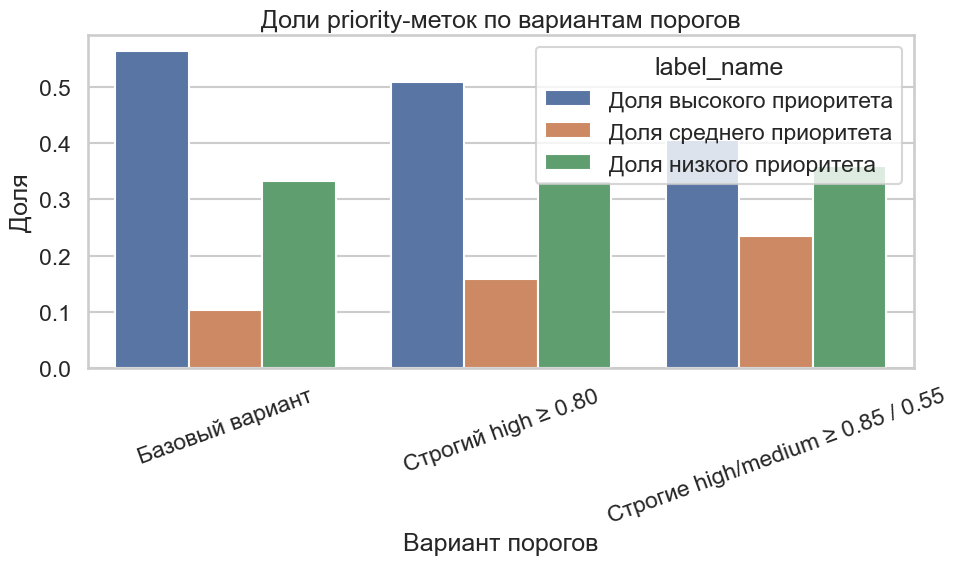

In [6]:
# Визуальный обзор: доли по вариантам порогов.
plot_df = variant_summary_df.loc[:, ['variant_name', 'share_high', 'share_medium', 'share_low']].melt(
    id_vars='variant_name',
    var_name='label_name',
    value_name='share',
)
plot_df['variant_name'] = plot_df['variant_name'].map(
    lambda value: PRIORITY_THRESHOLD_VARIANT_LABELS.get(str(value), str(value))
)
plot_df['label_name'] = plot_df['label_name'].map(
    lambda value: PRIORITY_THRESHOLD_SHARE_LABELS.get(str(value), str(value))
)
sns.barplot(data=plot_df, x='variant_name', y='share', hue='label_name')
plt.title('Доли priority-меток по вариантам порогов')
plt.xlabel('Вариант порогов')
plt.ylabel('Доля')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [7]:
# Переходы меток относительно базового варианта для более строгих порогов.
strict_high_transition_df = build_priority_label_transition_frame(
    priority_review_df,
    variant=PRIORITY_THRESHOLD_VARIANTS[1],
)
strict_high_medium_transition_df = build_priority_label_transition_frame(
    priority_review_df,
    variant=PRIORITY_THRESHOLD_VARIANTS[2],
)

display(
    rename_frame_for_display(
        strict_high_transition_df,
        column_mapping={
            'baseline_label': 'Базовая метка',
            'variant_label': 'Метка в строгом варианте',
            'n_rows': 'Число строк',
            'share': 'Доля',
        },
        value_mapping={
            'baseline_label': PRIORITY_LABELS,
            'variant_label': PRIORITY_LABELS,
        },
    )
)
display(
    rename_frame_for_display(
        strict_high_medium_transition_df,
        column_mapping={
            'baseline_label': 'Базовая метка',
            'variant_label': 'Метка в самом строгом варианте',
            'n_rows': 'Число строк',
            'share': 'Доля',
        },
        value_mapping={
            'baseline_label': PRIORITY_LABELS,
            'variant_label': PRIORITY_LABELS,
        },
    )
)


,Базовая метка,Метка в строгом варианте,Число строк,Доля
0,Высокий,Высокий,90293,0.508195
1,Низкий,Низкий,59128,0.332789
2,Средний,Средний,18373,0.103408
3,Высокий,Средний,9880,0.055607


,Базовая метка,Метка в самом строгом варианте,Число строк,Доля
0,Высокий,Высокий,72048,0.405507
1,Низкий,Низкий,59128,0.332789
2,Высокий,Средний,28125,0.158296
3,Средний,Средний,13726,0.077254
4,Средний,Низкий,4647,0.026155


In [8]:
# Граница порогов: строки, ближайшие к текущим и предлагаемым значениям high.
boundary_df = priority_review_df.loc[:, ['source_id', 'priority_score', 'priority_label', 'final_coarse_class', 'priority_reason']].copy()
boundary_df['distance_to_075'] = (boundary_df['priority_score'] - 0.75).abs()
boundary_df['distance_to_085'] = (boundary_df['priority_score'] - 0.85).abs()

display(
    rename_frame_for_display(
        boundary_df.sort_values('distance_to_075', ascending=True, kind='mergesort').head(15),
        column_mapping={
            'source_id': 'source_id',
            'priority_score': 'priority_score',
            'priority_label': 'Уровень приоритета',
            'final_coarse_class': 'Итоговый coarse-класс',
            'priority_reason': 'Причина приоритета',
            'distance_to_075': 'Расстояние до 0.75',
            'distance_to_085': 'Расстояние до 0.85',
        },
        value_mapping={'priority_label': PRIORITY_LABELS},
    )
)
display(
    rename_frame_for_display(
        boundary_df.sort_values('distance_to_085', ascending=True, kind='mergesort').head(15),
        column_mapping={
            'source_id': 'source_id',
            'priority_score': 'priority_score',
            'priority_label': 'Уровень приоритета',
            'final_coarse_class': 'Итоговый coarse-класс',
            'priority_reason': 'Причина приоритета',
            'distance_to_075': 'Расстояние до 0.75',
            'distance_to_085': 'Расстояние до 0.85',
        },
        value_mapping={'priority_label': PRIORITY_LABELS},
    )
)


,source_id,priority_score,Уровень приоритета,Итоговый coarse-класс,Причина приоритета,Расстояние до 0.75,Расстояние до 0.85
100172,3102018212324700928,0.750004,Высокий,F,сильный host-like сигнал,0.000004,0.099996
100171,221547817723039104,0.750005,Высокий,F,сбалансированный профиль без явных экстремумов,0.000005,0.099995
100170,6299381185324265344,0.750021,Высокий,F,сбалансированный профиль без явных экстремумов,0.000021,0.099979
100173,3102787556925152128,0.749974,Средний,G,сильный host-like сигнал,0.000026,0.100026
100174,641993264522182784,0.749973,Средний,M,сильный host-like сигнал; ограниченная наблюда...,0.000027,0.100027
100175,3326929118281225216,0.749972,Средний,K,сильный host-like сигнал; ограниченная наблюда...,0.000028,0.100028
100176,2101493687950465920,0.749972,Средний,G,сильный host-like сигнал,0.000028,0.100028
100169,2130741938499592320,0.750029,Высокий,K,сильный host-like сигнал,0.000029,0.099971
100177,2135116586029971072,0.749971,Средний,K,сильный host-like сигнал,0.000029,0.100029
100178,5420629128515354624,0.749970,Средний,F,сбалансированный профиль без явных экстремумов,0.000030,0.100030


,source_id,priority_score,Уровень приоритета,Итоговый coarse-класс,Причина приоритета,Расстояние до 0.75,Расстояние до 0.85
72048,326198166222715264,0.849999,Высокий,K,сильный host-like сигнал,0.099999,7.439439e-07
72047,5240343817519314944,0.850001,Высокий,K,сильный host-like сигнал,0.100001,1.257775e-06
72049,5079227259097931392,0.849999,Высокий,F,сильный host-like сигнал,0.099999,1.326385e-06
72046,3234733217162813440,0.850001,Высокий,G,сильный host-like сигнал,0.100001,1.355165e-06
72050,161743593580224512,0.849997,Высокий,G,сильный host-like сигнал,0.099997,2.724122e-06
72051,6063244678001320832,0.849996,Высокий,F,сильный host-like сигнал,0.099996,4.211156e-06
72045,6124654734537143936,0.850004,Высокий,G,сильный host-like сигнал,0.100004,4.451693e-06
72052,986739259896882688,0.849995,Высокий,K,сильный host-like сигнал,0.099995,4.804994e-06
72053,2102739576366631552,0.849994,Высокий,F,сильный host-like сигнал,0.099994,5.622281e-06
72054,2126875093545314688,0.849994,Высокий,F,сильный host-like сигнал,0.099994,5.683304e-06


## Как читать этот обзор

- Если более строгие пороги заметно сужают `high` без потери читаемости top-zone, scaling пока можно не трогать.
- Если `high` все еще слишком широкая даже после ужатия thresholds, следующим шагом открываем отдельный scaling review.
- Если class-level impact оказывается несбалансированным, thresholds надо принимать вместе с coarse-class policy, а не отдельно от нее.